In [37]:
# DATA

import pandas as pd
import numpy as np

# Set a random seed so my results are reproducible
np.random.seed(42)

# Fake participants
n = 200

# Creating the fake data
data = pd.DataFrame({
    'age': np.random.randint(18, 66, n),
    # age between 18-65
    
    'commute_distance': np.random.normal(10, 5, n).clip(0),  
    # average 10 miles, some variation, nothing below 0
    
    'session_length_min': np.random.choice([60, 120], n),
    # sessions were 60 or 120 minutes
    
    'sessions_completed': np.random.choice([1, 2, 3], n),
    # between 1-3 sessions, 4 means they finished the study
    
    'employment_status': np.random.choice(
        ['employed', 'unemployed', 'student'], n, 
        p=[0.6, 0.3, 0.1]  # 60% employed, 30% unemployed, 10% student
    )
})

# Making dropout predictability realistic, based on literature
dropout_probability = (
    0.3                                                # base rate
    # (longitudinal studies typically see 30-40% attrition)

    + 0.015 * data['commute_distance']                    
    # commute is a real but moderate predictor
    # 10 miles adds ~15%, 20 miles adds ~30%

    + 0.004 * data['session_length_min']                  
    # longer sessions increase burden
    # 60 min adds ~24%, 120 min adds ~48%

    - 0.18 * data['sessions_completed']                   
    # each session completed meaningfully reduces dropout risk
    # 1 session: -18%, 2 sessions: -36%, 3 sessions: -54%

    - 0.005 * (data['age'] - 18)                          
    # older participants slightly less likely to drop out
    # moderate effect, age 18 gets 0 penalty, age 65 gets -23%

    + 0.15 * (data['employment_status'] == 'unemployed')  
    # literature shows unemployed and students drop out more
    + 0.15 * (data['employment_status'] == 'student')

).clip(0, 1)
# keep probability between 0 and 1

data['dropped_out'] = (np.random.rand(n) < dropout_probability).astype(int)
# dropout_probability gives each person a probability that they dropped out
# but in reality, they either do or don't. To convert probability to a
# yes/no, I'll flip a WEIGHTED coin.
# one random number will be generated, "np.random.rand(n)", between 0-1 for all
# n = 200 people. For each person, if the number is LESS than their dropout
# probability, then they drop out (TRUE, 1). If MORE than their rate, they stay (FALSE, 0).
# 0 means they stayed, 1 means they dropped out.

# Preview
print(data.head(10))

print(f"\nDropout rate: {data['dropped_out'].mean():.1%}")
# calculates the average of the dropout column - average is the dropout rate (0 to 1)
# formatted as a percentage w/ one decimal place.

   age  commute_distance  session_length_min  sessions_completed  \
0   56          5.284716                  60                   2   
1   46         17.019794                 120                   2   
2   32          9.907246                 120                   2   
3   60          1.632477                  60                   1   
4   25          4.637341                 120                   1   
5   38          5.037069                 120                   3   
6   56         10.511738                  60                   2   
7   36          7.836954                 120                   3   
8   40          6.704088                  60                   1   
9   28         10.019687                  60                   1   

  employment_status  dropped_out  
0        unemployed            0  
1          employed            0  
2          employed            1  
3           student            0  
4          employed            1  
5           student            1  
6     


Dropout by Sessions Completed:
                    Total  Dropped_Out Dropout_Rate
sessions_completed                                 
1                      74           43        58.1%
2                      68           22        32.4%
3                      58           12        20.7%

Dropout by Session Length:
                    Total  Dropped_Out Dropout_Rate
session_length_min                                 
60                    110           30        27.3%
120                    90           47        52.2%

Dropout by Employment Status:
                   Total  Dropped_Out Dropout_Rate
employment_status                                 
employed             120           40        33.3%
student               17            8        47.1%
unemployed            63           29        46.0%

Dropout by Age Group:
           Total  Dropped_Out Dropout_Rate
age_group                                 
18-25         30           14        46.7%
26-35         37           15     

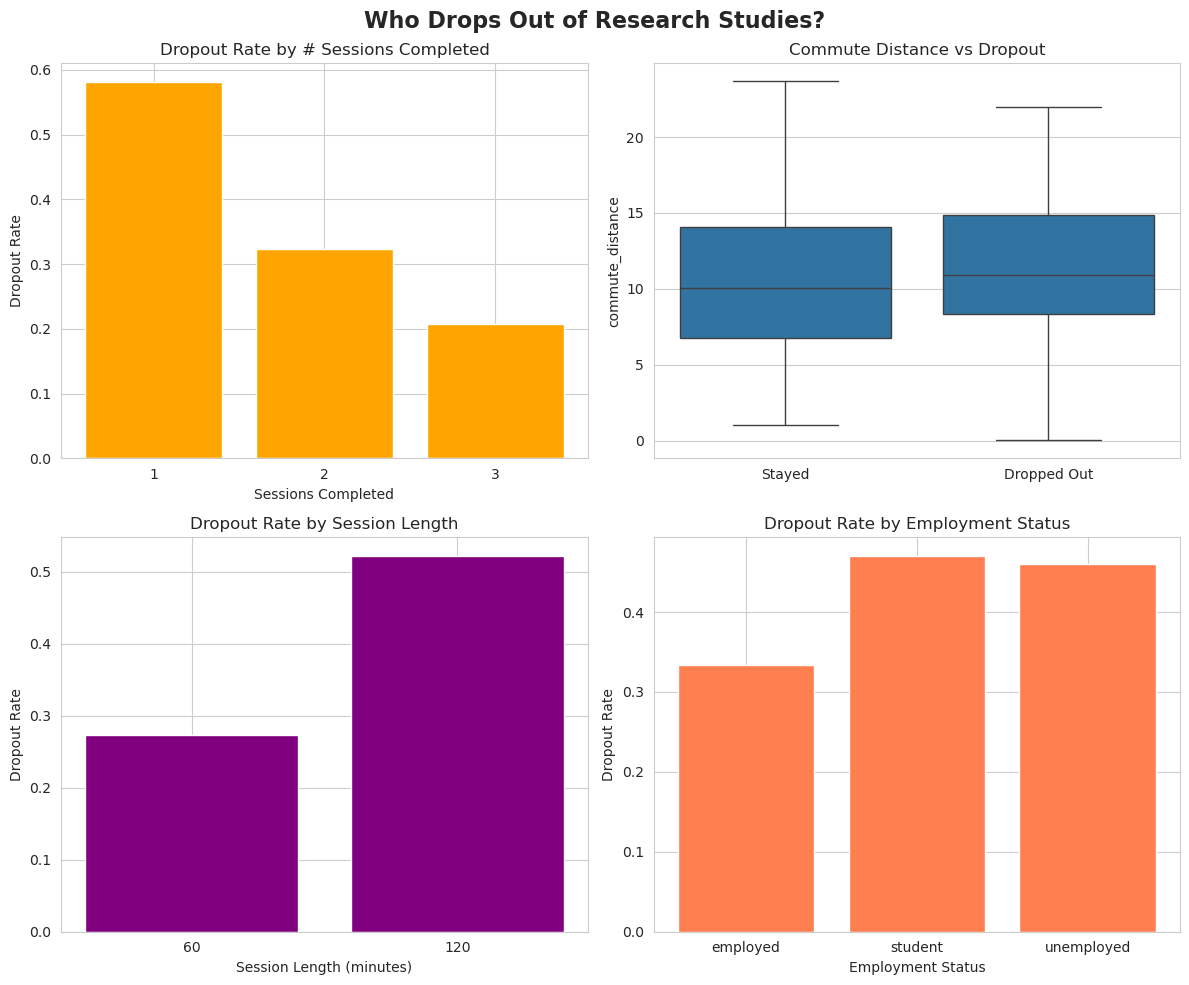

In [38]:
# TABLES and GRAPHS

import matplotlib.pyplot as plt
import seaborn as sns

# Descriptive stats - Within category dropout rates tables

# Sessions completed table
sessions_table = data.groupby('sessions_completed').agg(
    Total=('dropped_out', 'count'),
    Dropped_Out=('dropped_out', 'sum'),
    Dropout_Rate=('dropped_out', 'mean')
).round(3)
sessions_table['Dropout_Rate'] = (sessions_table['Dropout_Rate'] * 100).round(1).astype(str) + '%'
print("\nDropout by Sessions Completed:")
print(sessions_table.to_string())

# Session length table
session_length_table = data.groupby('session_length_min').agg(
    Total=('dropped_out', 'count'),
    Dropped_Out=('dropped_out', 'sum'),
    Dropout_Rate=('dropped_out', 'mean')
).round(3)
session_length_table['Dropout_Rate'] = (session_length_table['Dropout_Rate'] * 100).round(1).astype(str) + '%'
print("\nDropout by Session Length:")
print(session_length_table.to_string())

# Employment status table
employment_table = data.groupby('employment_status').agg(
    Total=('dropped_out', 'count'),
    Dropped_Out=('dropped_out', 'sum'),
    Dropout_Rate=('dropped_out', 'mean')
).round(3)
employment_table['Dropout_Rate'] = (employment_table['Dropout_Rate'] * 100).round(1).astype(str) + '%'
print("\nDropout by Employment Status:")
print(employment_table.to_string())

# Age table
# creating age ranges/bins
data['age_group'] = pd.cut(data['age'], 
                            bins=[18, 25, 35, 45, 55, 65], 
                            labels=['18-25', '26-35', '36-45', '46-55', '56-65'])

age_table = data.groupby('age_group', observed=True).agg(
    Total=('dropped_out', 'count'),
    Dropped_Out=('dropped_out', 'sum'),
    Dropout_Rate=('dropped_out', 'mean')
)
age_table['Dropout_Rate'] = (age_table['Dropout_Rate'] * 100).round(1).astype(str) + '%'
print("\nDropout by Age Group:")
print(age_table.to_string())

# Commute table
# create commute ranges/bins
data['commute_group'] = pd.cut(data['commute_distance'],
                                bins=[0, 5, 10, 15, 20, 100],
                                labels=['0-5 mi', '6-10 mi', '11-15 mi', '16-20 mi', '20+ mi'])

commute_table = data.groupby('commute_group', observed=True).agg(
    Total=('dropped_out', 'count'),
    Dropped_Out=('dropped_out', 'sum'),
    Dropout_Rate=('dropped_out', 'mean')
)
commute_table['Dropout_Rate'] = (commute_table['Dropout_Rate'] * 100).round(1).astype(str) + '%'
print("\nDropout by Commute Distance:")
print(commute_table.to_string())


# Set a clean visual style
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# creates a grid of charts, 2x2 so 4 total. 
# fig size, 12w x 10l

fig.suptitle('Who Drops Out of Research Studies?', fontsize=16, fontweight='bold')
# title of canvas

# Chart 1: Dropout by # of sessions completed
dropout_by_sessions_completed = data.groupby('sessions_completed')['dropped_out'].mean()
axes[0,0].bar(dropout_by_sessions_completed.index.astype(str), dropout_by_sessions_completed.values, color='orange')
axes[0,0].set_title('Dropout Rate by # Sessions Completed')
axes[0,0].set_xlabel('Sessions Completed')
axes[0,0].set_ylabel('Dropout Rate')

# Chart 2: Dropout by commute distance
sns.boxplot(data=data, x='dropped_out', y='commute_distance', ax=axes[0,1])
axes[0,1].set_title('Commute Distance vs Dropout')
axes[0,1].set_xticklabels(['Stayed', 'Dropped Out'])
axes[0,1].set_xlabel('')

# Chart 3: Dropout rate by session length
dropout_by_session = data.groupby('session_length_min')['dropped_out'].mean()
axes[1,0].bar(dropout_by_session.index.astype(str), dropout_by_session.values, color='purple')
axes[1,0].set_title('Dropout Rate by Session Length')
axes[1,0].set_xlabel('Session Length (minutes)')
axes[1,0].set_ylabel('Dropout Rate')

# Chart 4: Dropout rate by employment status
dropout_by_employment = data.groupby('employment_status')['dropped_out'].mean()
axes[1,1].bar(dropout_by_employment.index, dropout_by_employment.values, color='coral')
axes[1,1].set_title('Dropout Rate by Employment Status')
axes[1,1].set_xlabel('Employment Status')
axes[1,1].set_ylabel('Dropout Rate')

plt.tight_layout()
# adjusts spacing between charts so not cramped

plt.savefig('dropout_exploration.png', dpi=150, bbox_inches='tight')
# saves canvas as an image file

plt.show()
# shows chart

In [39]:
# PREDICTION MODEL

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
# splits data into two portions
from sklearn.metrics import classification_report, confusion_matrix
# grade how well model did
from sklearn.preprocessing import LabelEncoder
# converts text categories into numbers to read better

import warnings
warnings.filterwarnings('ignore')
# silences warnings

# Convert employment_status from words to numbers
# (models only understand numbers)
le = LabelEncoder()
# label encoder tool

data['employment_encoded'] = le.fit_transform(data['employment_status'])
# figures out how to encode + transform the data in employment status
# new table called employment_encoded, this new data saved in there

# Define features (inputs) and target (what I'm predicting)
features = ['age', 'commute_distance', 'session_length_min', 
            'sessions_completed', 'employment_encoded' 
           ]
#all in numbers version

X = data[features]          # creates table of input columns
y = data['dropped_out']     # what we're predicting, uses j dropped_out value

# Split into training data and test data
# Train on 80%, test on 20%, standard practice
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# training to predict if given new data, bc will j use old data and predict perfectly
# which is not the goal, we want to use this model w new data not j old data
# so some data is hidden during training so it doesn't know all, and then used after
# test_size keeps 20% hidden as test data, remaining 80% is training data

# Train the model
model = LogisticRegression(max_iter=1000)
# this creates the model 
# max_iter is how many attempts it gets to find the best solution
model.fit(X_train, y_train)
# fit means learn from this data, given the x training (our data) and y training data (predictions)

# See how well it did
y_pred = model.predict(X_test)
# shows the model the 40 (20%) it hasn't seen before and asks it to predict who dropped out
# produces a list of 0s and 1s, guesses, stored in y_pred

# y_test - the real answers for that 20%
# y_pred - the model's predictions/guesses for that 20%
# you can now compare the performance

print("Model Performance:")
print(classification_report(y_test, y_pred, 
      target_names=['Stayed', 'Dropped Out']))

# accuracy = out of 20%, 40 people, what % did model get right? (f1-score)
# precision = when model said someone dropped out, how often was it right? high is good
# recall = out of everyone who actually dropped out, how many did the model catch? high means caught more
# f1-score = combined score that balances precision and recall together
# support = how many people in each group were in my test group 
# stayed is coded as 0, dropped out is 1


Model Performance:
              precision    recall  f1-score   support

      Stayed       0.64      0.94      0.76        17
 Dropped Out       0.93      0.61      0.74        23

    accuracy                           0.75        40
   macro avg       0.79      0.77      0.75        40
weighted avg       0.81      0.75      0.75        40



               Factor  Importance
2  session_length_min    0.029870
0                 age    0.030233
1    commute_distance    0.077148
4  employment_encoded    0.381122
3  sessions_completed    1.103792


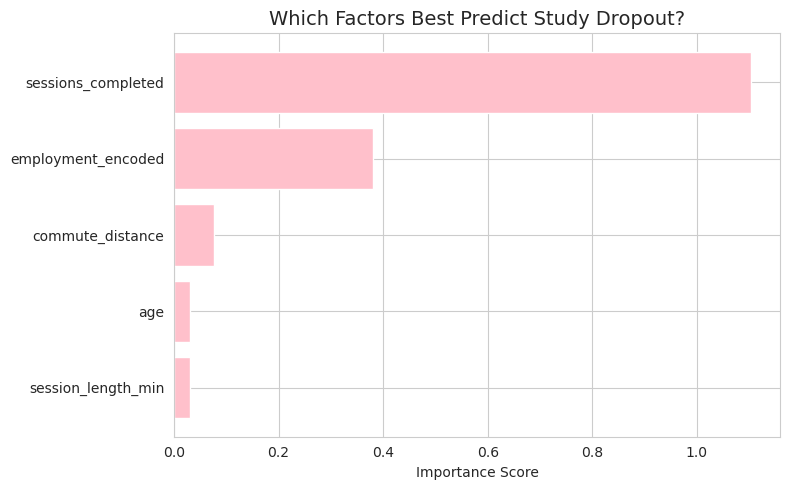

In [40]:
# WHAT FACTORS WERE MOST IMPORTANT FOR PREDICTION

coefficients = pd.DataFrame({
    'Factor': features,
    'Importance': abs(model.coef_[0]) 
    # abs() makes everything positive for easier comparison (for the neg values previously)
    # mode.coef = when training log reg model, it stores a # for each input variable, coefficient
    # shows how much each factor influenced predictions
    # 2 items, 2 column table using pd.dataframe
    # factor = input variables, from features list
    # importance = abs value of each coefficient
}).sort_values('Importance', ascending=True)
# sorts table by importance from small to large

plt.figure(figsize=(8, 5))
# creates chart 8w x 5l
plt.barh(coefficients['Factor'], coefficients['Importance'], color='pink')
# horizontal bar chart (h), left to right, better for long title variables
# coefficients[factor] = y axis labels
# coefficients[importance] = length of each bar, importance score

plt.title('Which Factors Best Predict Study Dropout?', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
# fixes spaces issues
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
print(coefficients)
plt.show()